# Step C — Battery storage

**Task (Assignment 1, part c):** Add one (or more) storage technology to the Step A model
and investigate how it behaves and what its impact is on the optimal system configuration.
Discuss which balancing strategies the system is using at different time scales
(intraday, multi-day, seasonal).

**Approach:**
1. Start from the single-node Denmark model of Step A.
2. Add a `StorageUnit` representing a Li-ion battery with **2020** cost data. Observe
   that the battery is not competitive at those costs.
3. Re-run with **2024** battery costs (which have collapsed ~80 % since 2020) and
   analyse capacity mix, dispatch, SoC patterns and balancing strategy.

**Requires in the working directory:**
- `DK_2015_merged.csv`
- `functions_to_investigate.py`


## Imports

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import importlib
import functions_to_investigate as fti


## Rebuild the Step A baseline

Step C compares capacities *with* and *without* storage, so we need the Step A network
(`dnk_n`). We rebuild it here so this notebook is self-contained.


In [24]:
# Load 2015 Danish data
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
demand_dk = dataframe_dk["DK_load_actual_entsoe_transparency"]
CF_wind = dataframe_dk["wind_cf_Unnamed: 1"]
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"]

# Technology cost table (same as Step A)
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25 + 14000,    # solar:  46,000 $/MW/year
        700000/25 + 24000,    # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

# Step A network (needed later for the storage-vs-no-storage comparison)
dnk_n = pypsa.Network()
dnk_n.set_snapshots(dataframe_dk.index.values)
dnk_n.add("Bus", "Denmark")
dnk_n.add("Carrier", ["wind_combined", "solar", "CCGT"], color=["blue", "red", "brown"])
dnk_n.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)
dnk_n.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
          capital_cost=costs.loc["wind_combined", "capital_cost"],
          marginal_cost=costs.loc["wind_combined", "marginal_cost"],
          p_max_pu=CF_wind.values, p_nom_extendable=True)
dnk_n.add("Generator", "solar", bus="Denmark", carrier="solar",
          capital_cost=costs.loc["solar", "capital_cost"],
          marginal_cost=costs.loc["solar", "marginal_cost"],
          p_max_pu=CF_solar.values, p_nom_extendable=True)
dnk_n.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
          capital_cost=costs.loc["CCGT", "capital_cost"],
          marginal_cost=costs.loc["CCGT", "marginal_cost"],
          efficiency=0.58, p_nom_extendable=True)
dnk_n.optimize(solver_name="highs", solver_options={"output_flag": False})
print(f"Step A rebuilt — system cost: {dnk_n.objective/1e9:.3f} B$/y")


C:\Users\terry\AppData\Local\Temp\ipykernel_24252\1238331835.py:36: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - output_flag: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 176.68it/s]
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.87e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.

Step A rebuilt — system cost: 1.873 B$/y


## Battery Storage Assumptions (Li-ion, 2020)

| Parameter | Value | Unit |
|---|---|---|
| Investment (power) | 150,000 | $/MW |
| Investment (energy) | 400,000 | $/MWh |
| Fixed O&M | 60,800 | $/MW/year |
| Efficiency (round-trip) | 85% | - |
| Lifetime | 15 | years |
| Max hours (E/P ratio) | 6 | h |
| Marginal cost | 0 | $/MWh |

**Source:** GNESTE database (2020 median values)

### Combined capital cost for PyPSA `StorageUnit`
```
capital_cost = Investment_power/lifetime + FOM + (Investment_energy/lifetime) × max_hours
             = 150,000/15 + 60,800 + (400,000/15) × 6
             = 10,000 + 60,800 + 160,000
             = 230,800 $/MW/year
```


In [25]:
# Costs (2020 Li-ion)
battery_investment_power = 150000    # $/MW
battery_investment_energy = 400000   # $/MWh
battery_fom = 60800                  # $/MW/year
battery_lifetime = 15                # years
battery_max_hours = 6                # hours (E/P ratio)
battery_efficiency = 0.85            # round-trip
battery_marginal_cost = 0            # $/MWh

# Combined capital cost for PyPSA StorageUnit
battery_capital_cost = (battery_investment_power / battery_lifetime
                        + battery_fom
                        + (battery_investment_energy / battery_lifetime) * battery_max_hours)

print(f"Battery capital cost: {battery_capital_cost:.0f} $/MW/year")


Battery capital cost: 230800 $/MW/year


In [26]:
# Build the network with 2020 battery
dnk_storage_2020 = pypsa.Network()
dnk_storage_2020.set_snapshots(dataframe_dk.index.values)
dnk_storage_2020.add("Bus", "Denmark")
dnk_storage_2020.add("Carrier", ["wind_combined", "solar", "CCGT", "battery"],
                     color=["blue", "red", "brown", "purple"])

dnk_storage_2020.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)

dnk_storage_2020.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
                     capital_cost=costs.loc["wind_combined", "capital_cost"],
                     marginal_cost=costs.loc["wind_combined", "marginal_cost"],
                     p_max_pu=CF_wind.values, p_nom_extendable=True)

dnk_storage_2020.add("Generator", "solar", bus="Denmark", carrier="solar",
                     capital_cost=costs.loc["solar", "capital_cost"],
                     marginal_cost=costs.loc["solar", "marginal_cost"],
                     p_max_pu=CF_solar.values, p_nom_extendable=True)

dnk_storage_2020.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
                     capital_cost=costs.loc["CCGT", "capital_cost"],
                     marginal_cost=costs.loc["CCGT", "marginal_cost"],
                     efficiency=0.58, p_nom_extendable=True)

# Battery (2020 costs)
dnk_storage_2020.add("StorageUnit", "battery", bus="Denmark", carrier="battery",
                     capital_cost=battery_capital_cost,
                     marginal_cost=battery_marginal_cost,
                     efficiency_store=battery_efficiency**0.5,
                     efficiency_dispatch=battery_efficiency**0.5,
                     max_hours=battery_max_hours,
                     cyclic_state_of_charge=True,
                     p_nom_extendable=True)


### Optimise (2020 costs)

In [27]:
dnk_storage_2020.optimize(solver_name="gurobi")


C:\Users\terry\AppData\Local\Temp\ipykernel_24252\516494256.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 259.67it/s]
INFO:linopy.io: Writing time: 0.16s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Solved in 17121 iterations and 2.01 seconds (1.24 work units)


INFO:gurobipy:Solved in 17121 iterations and 2.01 seconds (1.24 work units)


Optimal objective  1.872718568e+09


INFO:gurobipy:Optimal objective  1.872718568e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122644 duals
Objective: 1.87e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

### Results (2020 costs)

In [28]:
print("Results with 2020 battery costs\n")
print("Optimal Capacities [MW]:")
print(dnk_storage_2020.generators.p_nom_opt)
print(f"\nBattery: {dnk_storage_2020.storage_units.p_nom_opt['battery']:.1f} MW")
print(f"Battery energy: {dnk_storage_2020.storage_units.p_nom_opt['battery'] * battery_max_hours:.1f} MWh")


Results with 2020 battery costs

Optimal Capacities [MW]:
name
wind_combined    6100.444823
solar            3265.428127
CCGT             5336.670712
Name: p_nom_opt, dtype: float64

Battery: 0.0 MW
Battery energy: 0.0 MWh


### Observation: Battery storage is not competitive with 2020 costs

With 2020 cost assumptions (GNESTE database), the optimizer installs essentially **zero battery capacity**.
The annualized battery cost of 230,800 USD/MW/year far exceeds the maximum arbitrage revenue the
battery can earn in this system.

The battery profits by charging at 0 USD/MWh (during renewable surplus) and discharging at ~63.4 USD/MWh
(when CCGT sets the price). With a round-trip efficiency of 85% and 6 hours of storage:

**Max annual revenue ≈ 63.4 × 0.85 × 6h × 365 ≈ 118,000 USD/MW/year  <<  230,800 USD/MW/year**

This result is consistent with reality: according to IRENA, battery storage project costs declined 93%
between 2010 and 2024 (from 2,571 to 192 USD/kWh), and utility-scale batteries only became widely
competitive around 2022–2023.

To investigate the **impact and behavior** of storage on the system, we re-run the optimization using
updated 2024 cost assumptions (BloombergNEF, NREL ATB 2024).


### Updated assumptions: Battery storage with 2024 costs

With 2024 cost assumptions, battery storage becomes economically viable. Li-ion cell prices have
dropped dramatically due to manufacturing overcapacity, LFP chemistry adoption, and intense
competition — particularly from Chinese manufacturers.

| Parameter | 2020 | 2024 | Change |
|---|---|---|---|
| Investment (power) | 150,000 USD/MW | 100,000 USD/MW | -33% |
| Investment (energy) | 400,000 USD/MWh | 150,000 USD/MWh | -63% |
| Fixed O&M | 60,800 USD/MW/year | 12,500 USD/MW/year | -79% |
| Lifetime | 15 years | 20 years | +33% |
| Max hours (E/P ratio) | 6 h | 4 h | -33% |
| Round-trip efficiency | 85% | 90% | +5pp |
| **Annualized capital cost** | **230,800 USD/MW/year** | **47,500 USD/MW/year** | **-79%** |

The annualized cost drops from 230,800 to 47,500 USD/MW/year, well below the maximum arbitrage
revenue of approximately 83,000 USD/MW/year (63.4 × 0.90 × 4h × 365). We observe if the battery is now profitable.

**Source:** BloombergNEF Energy Storage System Cost Survey 2024, NREL ATB 2024.


In [29]:
# Updated Battery Li-ion assumptions (2024)
battery_investment_power = 100000    # $/MW
battery_investment_energy = 150000   # $/MWh
battery_fom = 12500                  # $/MW/year
battery_lifetime = 20                # years
battery_max_hours = 4                # hours (E/P ratio)
battery_efficiency = 0.90            # round-trip
battery_marginal_cost = 0            # $/MWh

battery_capital_cost_2024 = (battery_investment_power / battery_lifetime
                             + battery_fom
                             + (battery_investment_energy / battery_lifetime) * battery_max_hours)

print(f"Battery capital cost (2024): {battery_capital_cost_2024:.0f} $/MW/year")


Battery capital cost (2024): 47500 $/MW/year


In [30]:
# Create network with 2024 battery costs
dnk_storage = pypsa.Network()
dnk_storage.set_snapshots(dataframe_dk.index.values)
dnk_storage.add("Bus", "Denmark")
dnk_storage.add("Carrier", ["wind_combined", "solar", "CCGT", "battery"],
                color=["blue", "red", "brown", "purple"])
# Load
dnk_storage.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)

# Generators (same as Step A)
dnk_storage.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
                capital_cost=costs.loc["wind_combined", "capital_cost"],
                marginal_cost=costs.loc["wind_combined", "marginal_cost"],
                p_max_pu=CF_wind.values, p_nom_extendable=True)

dnk_storage.add("Generator", "solar", bus="Denmark", carrier="solar",
                capital_cost=costs.loc["solar", "capital_cost"],
                marginal_cost=costs.loc["solar", "marginal_cost"],
                p_max_pu=CF_solar.values, p_nom_extendable=True)

dnk_storage.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
                capital_cost=costs.loc["CCGT", "capital_cost"],
                marginal_cost=costs.loc["CCGT", "marginal_cost"],
                efficiency=0.58, p_nom_extendable=True)

# Battery (2024 costs)
dnk_storage.add("StorageUnit", "battery", bus="Denmark", carrier="battery",
                capital_cost=battery_capital_cost_2024,
                marginal_cost=battery_marginal_cost,
                efficiency_store=battery_efficiency**0.5,
                efficiency_dispatch=battery_efficiency**0.5,
                max_hours=battery_max_hours,
                cyclic_state_of_charge=True,
                p_nom_extendable=True)


### Optimise (2024 costs)

In [31]:
dnk_storage.optimize(solver_name="gurobi")


C:\Users\terry\AppData\Local\Temp\ipykernel_24252\3665869223.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 184.72it/s]
INFO:linopy.io: Writing time: 0.22s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Solved in 11374 iterations and 3.18 seconds (1.05 work units)


INFO:gurobipy:Solved in 11374 iterations and 3.18 seconds (1.05 work units)


Optimal objective  1.843976080e+09


INFO:gurobipy:Optimal objective  1.843976080e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52564 primals, 122644 duals
Objective: 1.84e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

### Results (2024 costs)

In [32]:
print("Results with 2024 battery costs\n")
print("Optimal Capacities")
print(dnk_storage.generators.p_nom_opt)
print(f"\nBattery: {dnk_storage.storage_units.p_nom_opt['battery']:.1f} MW")
print(f"Battery energy: {dnk_storage.storage_units.p_nom_opt['battery'] * battery_max_hours:.1f} MWh")

print("\nAnnual Production [TWh]")
print(dnk_storage.generators_t.p.sum() / 1e6)

battery_discharge = dnk_storage.storage_units_t.p.clip(lower=0).sum().values[0] / 1e6
battery_charge = dnk_storage.storage_units_t.p.clip(upper=0).sum().values[0] / 1e6
print(f"\nBattery discharge: {battery_discharge:.2f} TWh")
print(f"Battery charge: {battery_charge:.2f} TWh")
print(f"Battery losses: {battery_discharge + battery_charge:.2f} TWh")


Results with 2024 battery costs

Optimal Capacities
name
wind_combined    6038.483085
solar            4488.609755
CCGT             4417.024994
Name: p_nom_opt, dtype: float64

Battery: 921.2 MW
Battery energy: 3684.7 MWh

Annual Production [TWh]
name
wind_combined    18.039211
solar             4.743038
CCGT             10.090366
dtype: float64

Battery discharge: 0.53 TWh
Battery charge: -0.58 TWh
Battery losses: -0.06 TWh


## Comparison: with vs without storage

In [33]:
# Comparison table with and without storage

comparison = pd.DataFrame({
    "Without Storage [GW]": [
        dnk_n.generators.p_nom_opt["wind_combined"] / 1e3,
        dnk_n.generators.p_nom_opt["solar"] / 1e3,
        dnk_n.generators.p_nom_opt["CCGT"] / 1e3,
        0,
    ],
    "With Storage [GW]": [
        dnk_storage.generators.p_nom_opt["wind_combined"] / 1e3,
        dnk_storage.generators.p_nom_opt["solar"] / 1e3,
        dnk_storage.generators.p_nom_opt["CCGT"] / 1e3,
        dnk_storage.storage_units.p_nom_opt["battery"] / 1e3,
    ],
}, index=["Wind", "Solar", "CCGT", "Battery"])

comparison["Δ [%]"] = ((comparison["With Storage [GW]"] - comparison["Without Storage [GW]"])
                      / comparison["Without Storage [GW]"].replace(0, float('nan')) * 100).round(1)

comparison


,Without Storage [GW],With Storage [GW],Δ [%]
Wind,6.100445,6.038483,-1.0
Solar,3.265428,4.488610,37.5
CCGT,5.336671,4.417025,-17.2
Battery,0.000000,0.921176,NaN


In [34]:
# Cost comparison with and without storage
cost_no_storage = dnk_n.objective / 1e9
cost_with_storage = dnk_storage.objective / 1e9

print(f"System cost without storage: {cost_no_storage:.3f} B$/y")
print(f"System cost with storage:    {cost_with_storage:.3f} B$/y")
print(f"Savings:                     {cost_no_storage - cost_with_storage:.3f} B$/y ({(cost_no_storage - cost_with_storage)/cost_no_storage*100:.1f}%)")


System cost without storage: 1.873 B$/y
System cost with storage:    1.844 B$/y
Savings:                     0.029 B$/y (1.5%)


## Dispatch with storage — summer and winter weeks

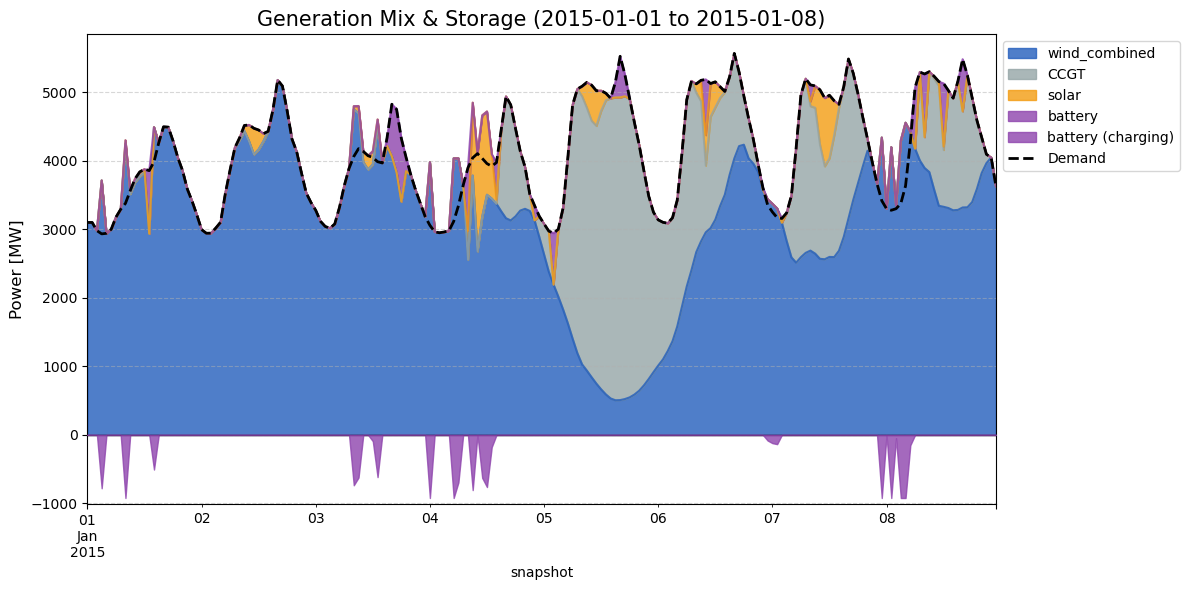

In [35]:
# Plot generation mix with storage for a January week
fti.plot_generation_mix_storage(dnk_storage, '2015-01-01', '2015-01-08')


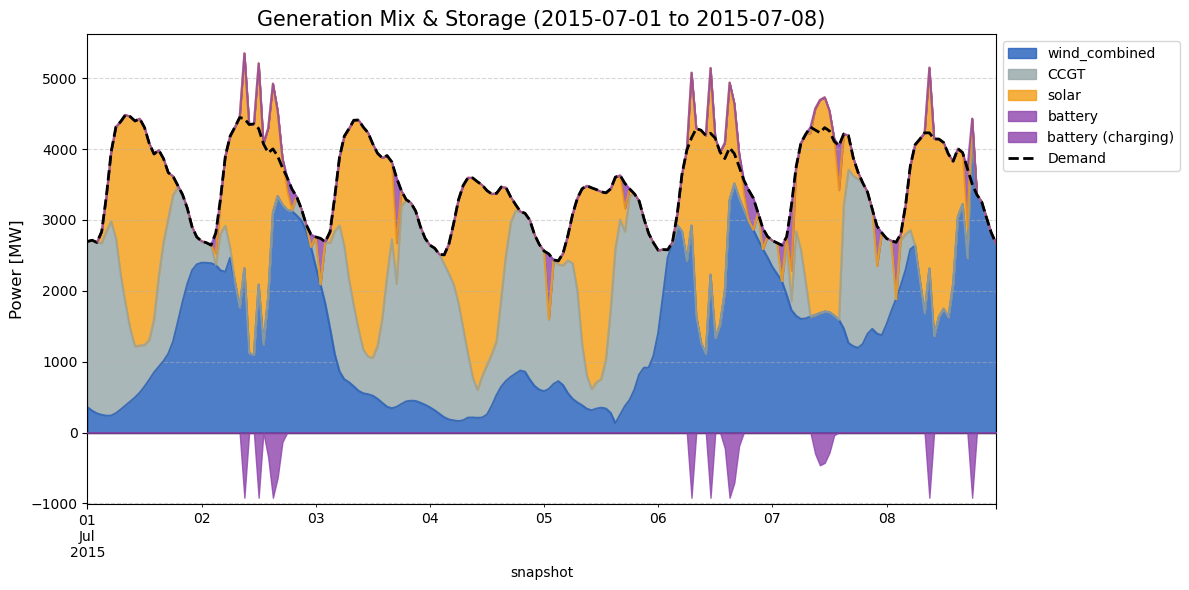

In [36]:
# Plot generation mix with storage for a July week
fti.plot_generation_mix_storage(dnk_storage, '2015-07-01', '2015-07-08')


## Battery state of charge — annual heatmap + summer/winter weeks

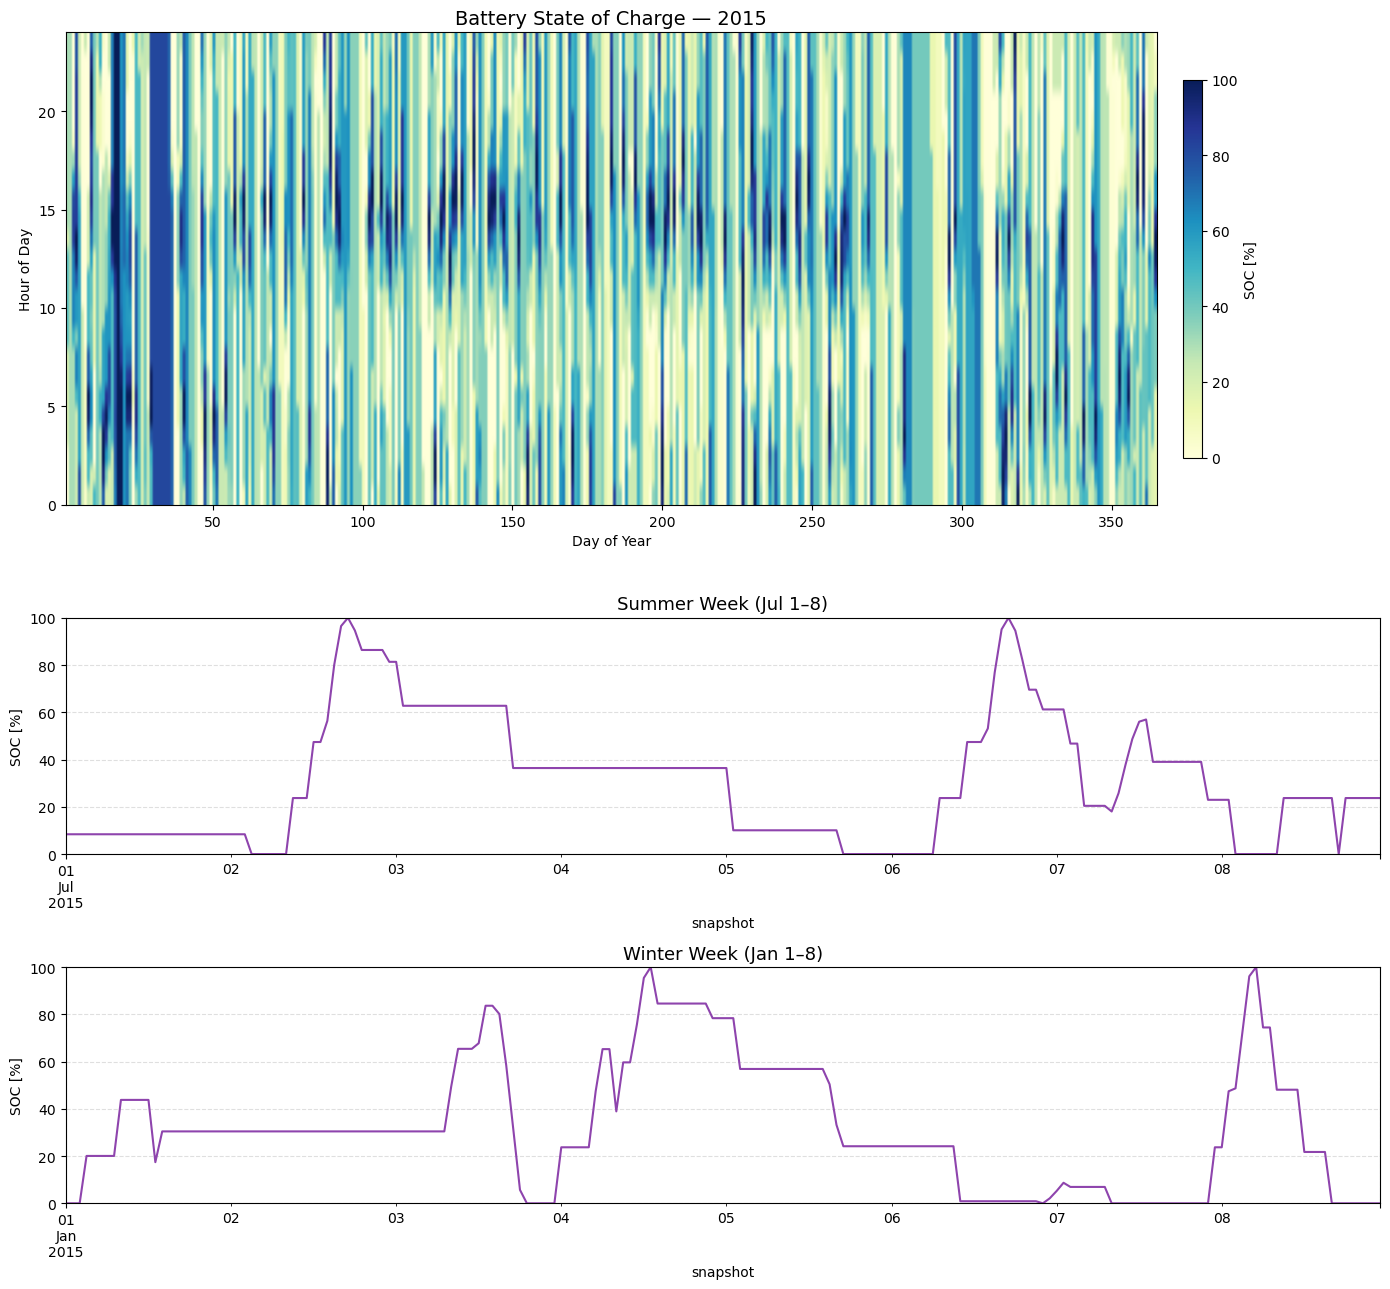

In [37]:
importlib.reload(fti)
fti.plot_battery_soc(dnk_storage, battery_max_hours)


The heatmap reveals that the battery does not follow a regular solar day/night cycle as one might expect.
Instead, it shows **vertical stripes**, charging and discharging driven by wind events lasting entire days.

This is consistent with Denmark's wind-dominated system (56% of the mix): the battery operates
opportunistically, charging during strong wind periods and discharging when wind drops, rather than
following a predictable intraday solar pattern.

The summer week zoom confirms irregular cycling tied to wind variability, while the winter week shows
more frequent and deeper cycles due to higher wind variability in the cold season.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


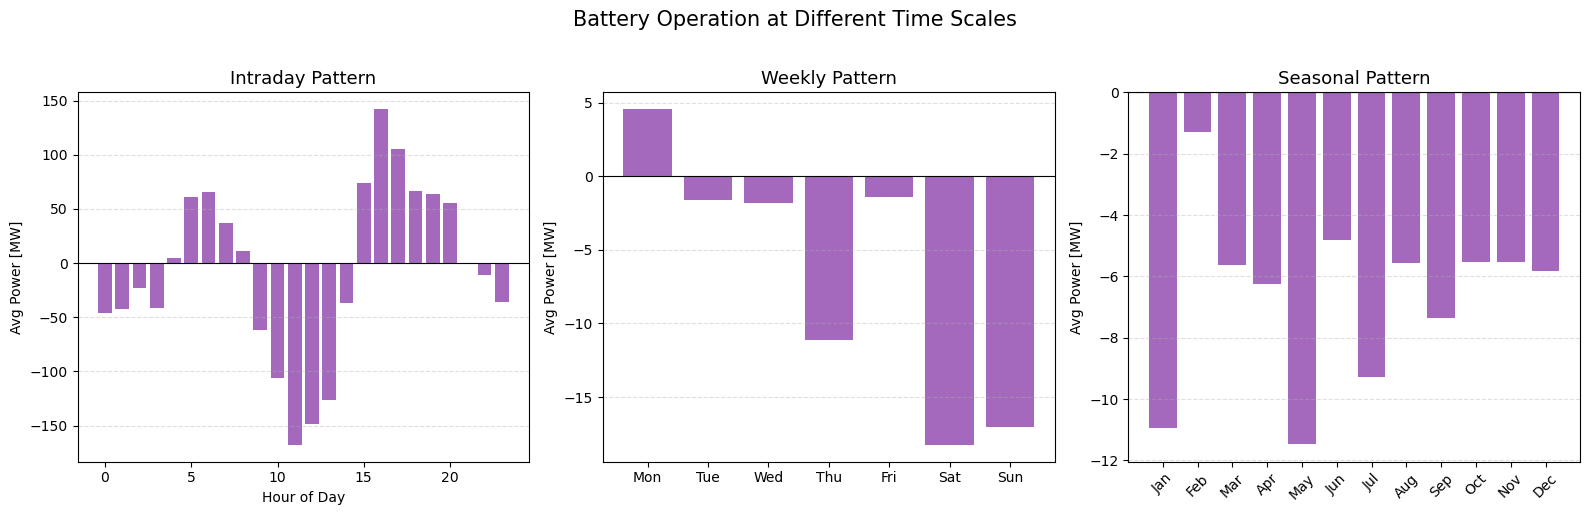

In [38]:
fti.plot_battery_timescales(dnk_storage)



- **Intraday:** A partial solar signature is visible (charging at midday, discharging in the evening),
  but the battery also charges overnight during wind surpluses. This confirms a mixed wind+solar driving pattern.

- **Weekly:** Average power is negative for all days (net consumer due to 10% round-trip losses).
  Activity peaks on certain days correlated with lower demand and higher wind.

- **Seasonal:** The battery is most active in **winter and spring** (January, March, November),
  not in summer. This is because winter brings higher wind variability, creating more arbitrage
  opportunities. In a system dominated by solar (e.g. Spain), the opposite pattern would be expected.

This confirms that the role of short-term storage is shaped by the **dominant renewable resource**
in the system, not by a universal solar driven cycle.


## Mismatch and annual mix with storage

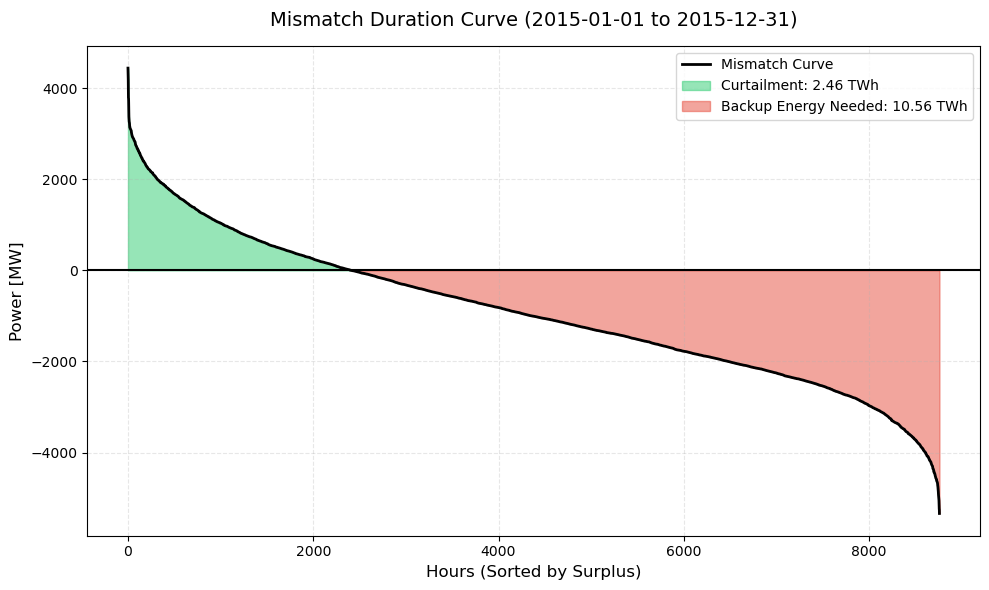

Analysis Results:
 - Total Potential Curtailment: 2.463 TWh
 - Total Backup Energy Needed:  10.558 TWh


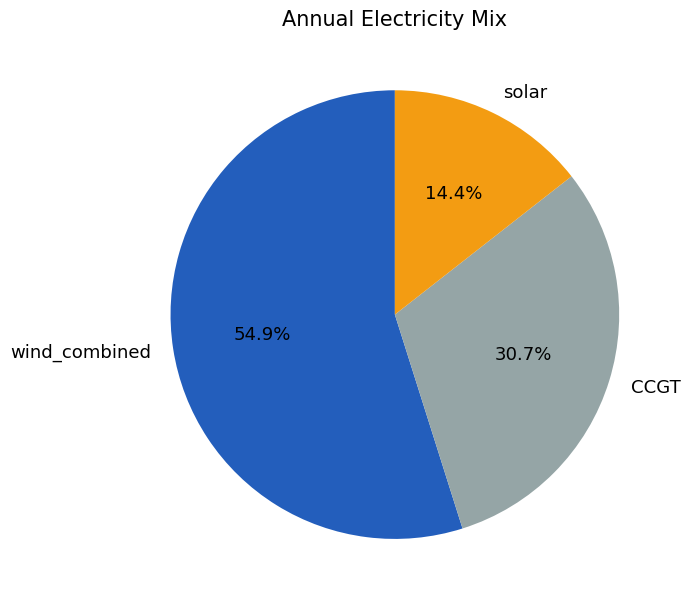

In [39]:
fti.plot_mismatch_analysis(dnk_storage, '2015-01-01', '2015-12-31')

fti.plot_annual_mix(dnk_storage)


Compared to the system without storage:
- **Curtailment increased** from 2.07 to 2.46 TWh (+19%): more solar is installed (4.5 vs 3.3 GW),
  producing more midday surplus than the battery can absorb.
- **CCGT backup decreased** from 11.25 to 10.56 TWh (-6%): replaced by solar + battery.
- **Solar share rose** from 9.7% to 13.4%, while **CCGT dropped** from 34.3% to 30.7%.

The 4 hour battery provides meaningful intraday balancing but cannot address multi-day or seasonal
wind variability. The CCGT remains essential for longer time scales. Eliminating it would require
long duration storage (hydrogen?) or interconnections with neighbouring countries (Step D).
